# Notebook 05 — Comprehensive Model Comparison

**Objective:** Compare three clustering algorithms using intrinsic metrics
and visualizations, then demonstrate the recommendation engine.

**Algorithms compared:**
1. **K-Means** — centroid-based, spherical clusters
2. **DBSCAN** — density-based, arbitrary shapes + noise detection
3. **Hierarchical (Agglomerative)** — tree-based, nested clusters

**Evaluation metrics:**
- Silhouette Score (higher = better)
- Davies-Bouldin Index (lower = better)
- Calinski-Harabasz Index (higher = better)

**Outputs:**
- `outputs/plots/14_dendrogram.png` — hierarchical clustering dendrogram
- `outputs/plots/15_hierarchical_results.png` — hierarchical results
- `outputs/plots/16_final_comparison.png` — all 3 algorithms side-by-side
- `outputs/plots/17_tsne_final.png` — t-SNE comparison of all 3

## 0. Setup & Imports

In [1]:
import os
import sys

NOTEBOOK_DIR = os.path.abspath("")
PROJECT_ROOT = os.path.dirname(NOTEBOOK_DIR)

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(f"Project root : {PROJECT_ROOT}")

Project root : c:\programmes\unsupervised-professional-matching


In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

from src.config import (
    RAW_DATA_PATH, PROCESSED_PATH, PLOTS_DIR,
    PCA_COMPONENTS, K_RANGE,
)
from src.models.clustering import (
    run_kmeans_experiment,
    plot_elbow_and_silhouette,
    fit_final_kmeans,
    profile_clusters,
    run_dbscan_experiment,
    plot_dbscan_results,
    fit_final_dbscan,
)
from src.models.hierarchical import (
    run_hierarchical_experiment,
    plot_dendrogram,
    plot_hierarchical_results,
    fit_final_hierarchical,
)
from src.models.compatibility import recommend_profiles
from src.evaluation.intrinsic_metrics import evaluate_clustering, compare_algorithms

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 130
plt.rcParams["savefig.bbox"] = "tight"
warnings.filterwarnings("ignore")
print("Imports complete")

Imports complete


In [3]:
X = np.load(PROCESSED_PATH)
print(f"Feature matrix shape : {X.shape}")

df_original = pd.read_csv(RAW_DATA_PATH)
print(f"Profiles loaded      : {len(df_original):,}")

vocab_path = os.path.join(PROJECT_ROOT, "data", "processed", "skill_vocab.txt")
with open(vocab_path) as f:
    skill_vocab = [line.strip() for line in f.readlines()]
print(f"Skill vocabulary     : {len(skill_vocab)} terms")

Feature matrix shape : (50000, 188)
Profiles loaded      : 50,000
Skill vocabulary     : 100 terms


## 1. Prepare PCA Space (shared by all algorithms)

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=PCA_COMPONENTS, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Original dimensions  : {X.shape[1]}")
print(f"PCA dimensions       : {X_pca.shape[1]}")
print(f"Variance retained    : {pca.explained_variance_ratio_.sum()*100:.2f}%")

Original dimensions  : 188
PCA dimensions       : 30
Variance retained    : 31.66%


## 2. K-Means — Centroid-Based Clustering

K-Means partitions data into K clusters by minimizing within-cluster variance.
It assumes clusters are spherical and of similar size.

In [5]:
print(f"Testing K from {K_RANGE.start} to {K_RANGE.stop - 1}...")
kmeans_results = run_kmeans_experiment(X_pca)

Testing K from 2 to 30...
Running K-Means for K = 2 to 30...
  K= 2 | inertia=2,846,247 | silhouette=0.0459
  K= 3 | inertia=2,762,514 | silhouette=0.0492
  K= 4 | inertia=2,688,252 | silhouette=0.0502
  K= 5 | inertia=2,613,779 | silhouette=0.0571
  K= 6 | inertia=2,541,138 | silhouette=0.0618
  K= 7 | inertia=2,480,004 | silhouette=0.0698
  K= 8 | inertia=2,403,068 | silhouette=0.0764
  K= 9 | inertia=2,331,753 | silhouette=0.0918
  K=10 | inertia=2,263,120 | silhouette=0.1027
  K=11 | inertia=2,195,768 | silhouette=0.1091
  K=12 | inertia=2,128,544 | silhouette=0.1197
  K=13 | inertia=2,051,739 | silhouette=0.1300
  K=14 | inertia=1,983,914 | silhouette=0.1407
  K=15 | inertia=1,923,626 | silhouette=0.1494
  K=16 | inertia=1,906,110 | silhouette=0.1371
  K=17 | inertia=1,891,264 | silhouette=0.1265
  K=18 | inertia=1,878,360 | silhouette=0.1152
  K=19 | inertia=1,870,744 | silhouette=0.0940
  K=20 | inertia=1,860,811 | silhouette=0.0930
  K=21 | inertia=1,850,543 | silhouette=0.0867

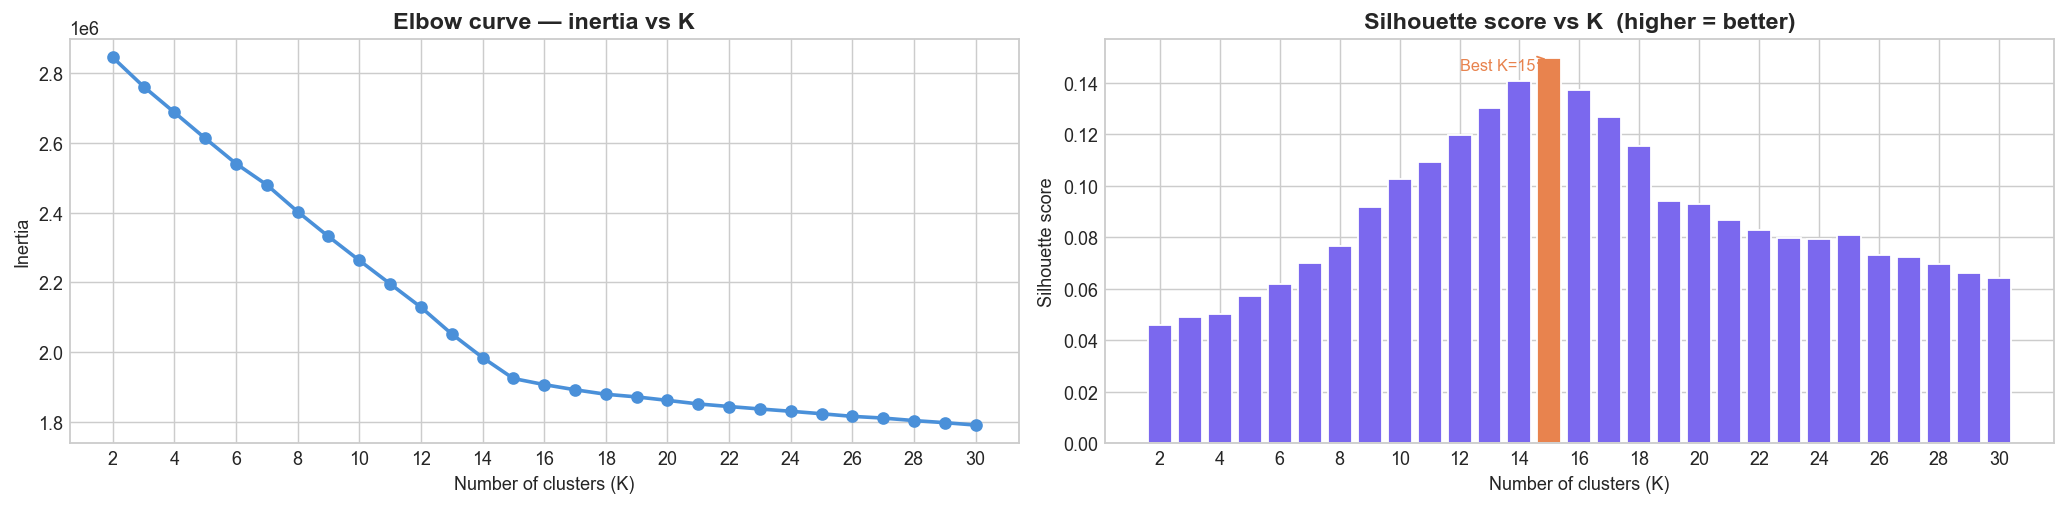


Best K by silhouette score: 15


In [6]:
plot_elbow_and_silhouette(kmeans_results)

In [7]:
BEST_K = int(kmeans_results.loc[kmeans_results["silhouette"].idxmax(), "k"])
print(f"Selected K : {BEST_K}")
print(f"\nFull results table:")
print(kmeans_results.to_string(index=False))

Selected K : 15

Full results table:
 k     inertia  silhouette
 2 2846247.000    0.045872
 3 2762513.500    0.049216
 4 2688252.000    0.050194
 5 2613779.250    0.057087
 6 2541137.500    0.061798
 7 2480003.750    0.069841
 8 2403068.000    0.076449
 9 2331753.000    0.091820
10 2263120.000    0.102726
11 2195768.250    0.109123
12 2128544.250    0.119728
13 2051739.375    0.129953
14 1983913.750    0.140701
15 1923625.500    0.149415
16 1906110.500    0.137097
17 1891264.375    0.126535
18 1878359.500    0.115198
19 1870744.375    0.094048
20 1860810.875    0.092978
21 1850543.250    0.086698
22 1843117.125    0.082806
23 1836063.125    0.079730
24 1829425.125    0.079384
25 1822374.375    0.080877
26 1814830.375    0.073290
27 1809926.125    0.072387
28 1802690.000    0.069562
29 1796739.125    0.066207
30 1789796.875    0.064107


In [8]:
kmeans_labels = fit_final_kmeans(X_pca, BEST_K)

✓ Final K-Means fitted  (K=15)
  Cluster sizes:
    Cluster 0: 3,322 profiles (6.6%)
    Cluster 1: 3,270 profiles (6.5%)
    Cluster 2: 3,355 profiles (6.7%)
    Cluster 3: 3,366 profiles (6.7%)
    Cluster 4: 3,333 profiles (6.7%)
    Cluster 5: 3,243 profiles (6.5%)
    Cluster 6: 3,355 profiles (6.7%)
    Cluster 7: 3,387 profiles (6.8%)
    Cluster 8: 3,242 profiles (6.5%)
    Cluster 9: 3,341 profiles (6.7%)
    Cluster 10: 3,318 profiles (6.6%)
    Cluster 11: 3,415 profiles (6.8%)
    Cluster 12: 3,296 profiles (6.6%)
    Cluster 13: 3,449 profiles (6.9%)
    Cluster 14: 3,308 profiles (6.6%)


In [9]:
kmeans_summary = profile_clusters(kmeans_labels, df_original, skill_vocab)
print("K-Means Cluster summary:")
print(kmeans_summary.to_string(index=False))

K-Means Cluster summary:
 cluster  size  pct_of_total                                                                top_skills  dominant_industry        dominant_role  median_exp top_seniority
       0  3322           6.6          vba, risk assessment, excel, claims analysis, financial modeling          Insurance      Product Manager         5.4           mid
       1  3270           6.5    spss, laboratory techniques, genomics, clinical trials, bioinformatics      Biotechnology  Engineering Manager         5.4           mid
       2  3355           6.7 business analysis, stakeholder management, project management, aws, excel         Consulting    Software Engineer         5.1           mid
       3  3366           6.7                 data visualization, healthcare analytics, r, python, spss         Healthcare         Scrum Master         5.4           mid
       4  3333           6.7                                     kubernetes, git, sql, tensorflow, aws         Technology        D

## 3. DBSCAN — Density-Based Clustering

DBSCAN groups points in dense regions and marks outliers as noise.
It can find clusters of arbitrary shape.

In [10]:
dbscan_results = run_dbscan_experiment(
    X_pca,
    eps_values=[0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.5, 0.6],
    min_samples_values=[5, 10, 20, 50],
    n_components=8
)

  Reduced to 8 components for DBSCAN (33.1% variance)
Running DBSCAN grid search: 32 combinations...
  [1/32] eps=0.15 min_samples=  5 | clusters= 96 | noise= 97.5% | sil=n/a
  [2/32] eps=0.15 min_samples= 10 | clusters=  3 | noise= 99.7% | sil=n/a
  [3/32] eps=0.15 min_samples= 20 | clusters=  0 | noise=100.0% | sil=n/a
  [4/32] eps=0.15 min_samples= 50 | clusters=  0 | noise=100.0% | sil=n/a
  [5/32] eps=0.20 min_samples=  5 | clusters=450 | noise= 75.2% | sil=-0.1862
  [6/32] eps=0.20 min_samples= 10 | clusters= 73 | noise= 91.2% | sil=n/a
  [7/32] eps=0.20 min_samples= 20 | clusters=  6 | noise= 97.3% | sil=n/a
  [8/32] eps=0.20 min_samples= 50 | clusters=  1 | noise= 99.9% | sil=n/a
  [9/32] eps=0.25 min_samples=  5 | clusters=198 | noise= 34.3% | sil=-0.4858
  [10/32] eps=0.25 min_samples= 10 | clusters= 59 | noise= 56.1% | sil=-0.3705
  [11/32] eps=0.25 min_samples= 20 | clusters= 42 | noise= 79.9% | sil=0.1273
  [12/32] eps=0.25 min_samples= 50 | clusters=  4 | noise= 95.3% | s

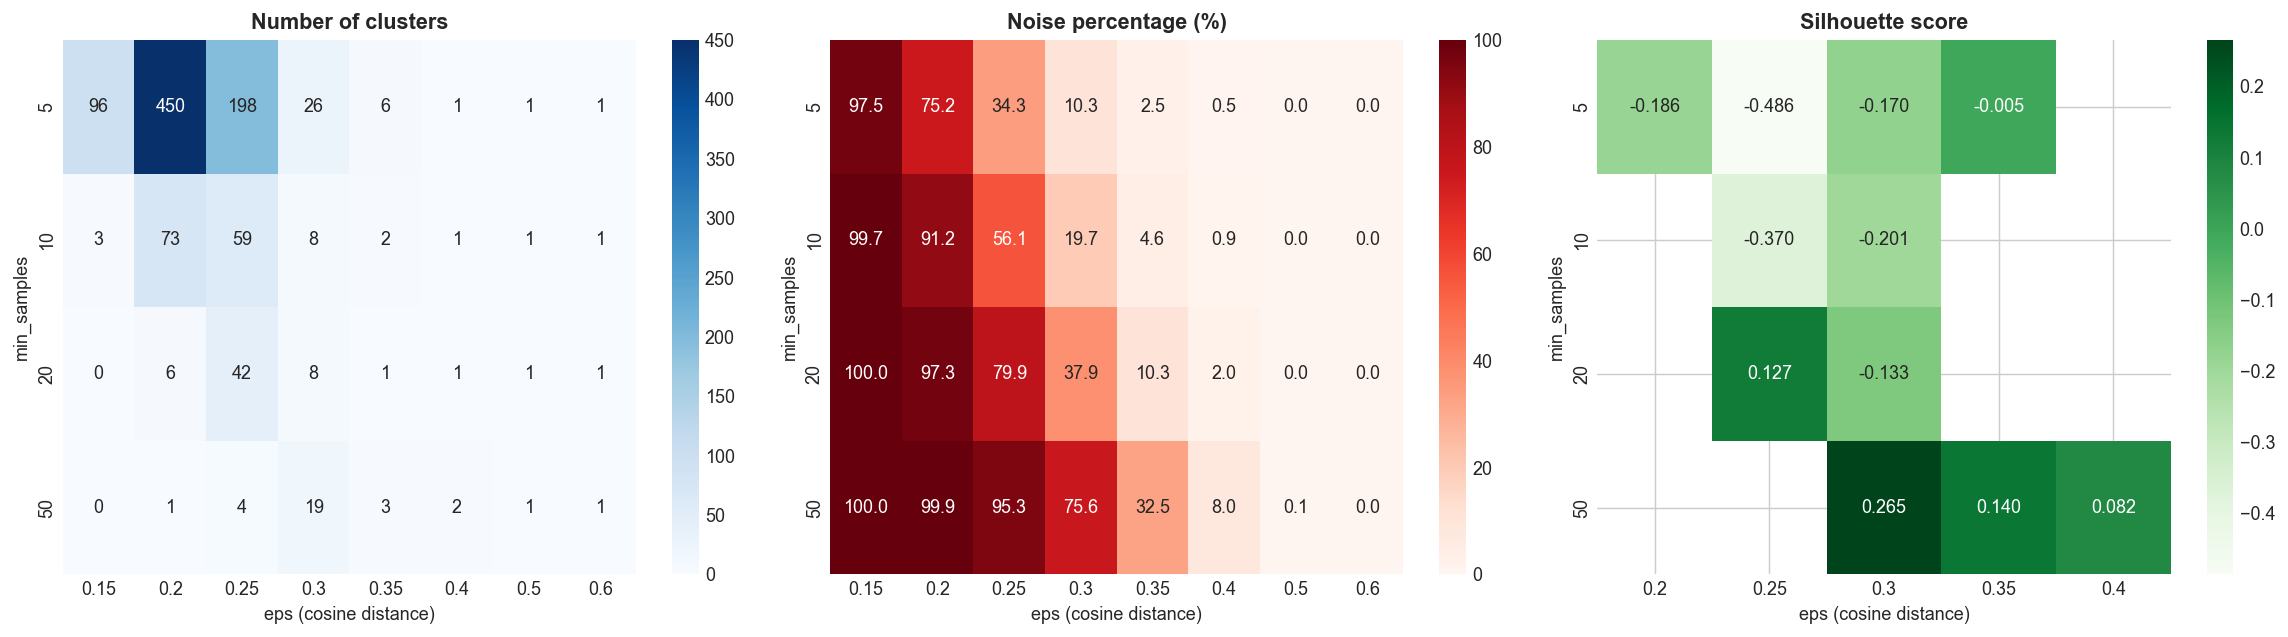


Best DBSCAN by silhouette:
  eps=0.3, min_samples=50.0 | clusters=19 | noise=75.6% | silhouette=0.2652


In [11]:
plot_dbscan_results(dbscan_results)

In [12]:
best_dbscan = dbscan_results.dropna(subset=["silhouette"])
if len(best_dbscan) > 0:
    best_row = best_dbscan.loc[best_dbscan["silhouette"].idxmax()]
    BEST_EPS = best_row["eps"]
    BEST_MIN_SAMPLES = int(best_row["min_samples"])
    print(f"Best DBSCAN params: eps={BEST_EPS}, min_samples={BEST_MIN_SAMPLES}")
    print(f"  Clusters: {int(best_row['n_clusters'])} | "
          f"Noise: {best_row['noise_pct']}% | "
          f"Silhouette: {best_row['silhouette']}")
else:
    BEST_EPS = 0.3
    BEST_MIN_SAMPLES = 50
    print("Using default DBSCAN params")

Best DBSCAN params: eps=0.3, min_samples=50
  Clusters: 19 | Noise: 75.6% | Silhouette: 0.2652


In [13]:
dbscan_labels = fit_final_dbscan(X_pca, eps=BEST_EPS, min_samples=BEST_MIN_SAMPLES,
                                 n_components=8)

✓ Final DBSCAN fitted  (eps=0.3, min_samples=50)
  Clusters found : 19
  Noise points   : 37,811 (75.6%)
  Cluster sizes:
    Cluster 0: 2,539 profiles (5.1%)
    Cluster 1: 1,515 profiles (3.0%)
    Cluster 2: 3,660 profiles (7.3%)
    Cluster 3: 1,150 profiles (2.3%)
    Cluster 4: 832 profiles (1.7%)
    Cluster 5: 1,212 profiles (2.4%)
    Cluster 6: 214 profiles (0.4%)
    Cluster 7: 71 profiles (0.1%)
    Cluster 8: 51 profiles (0.1%)
    Cluster 9: 255 profiles (0.5%)
    Cluster 10: 160 profiles (0.3%)
    Cluster 11: 146 profiles (0.3%)
    Cluster 12: 58 profiles (0.1%)
    Cluster 13: 102 profiles (0.2%)
    Cluster 14: 49 profiles (0.1%)
    Cluster 15: 49 profiles (0.1%)
    Cluster 16: 34 profiles (0.1%)
    Cluster 17: 53 profiles (0.1%)
    Cluster 18: 39 profiles (0.1%)


In [14]:
dbscan_summary = profile_clusters(dbscan_labels, df_original, skill_vocab)
print("DBSCAN Cluster summary:")
print(dbscan_summary.to_string(index=False))

DBSCAN Cluster summary:
 cluster  size  pct_of_total                                                               top_skills  dominant_industry        dominant_role  median_exp top_seniority
      -1 37811          75.6                       python, sql, statistics, machine learning, tableau             Retail Full Stack Developer        5.60           mid
       0  2539           5.1    e-learning, curriculum development, lms, instructional design, moodle          Education  Solutions Architect        5.20           mid
       1  1515           3.0             seo, analytics, content strategy, adobe creative suite, html              Media       Data Scientist        3.60         entry
       2  3660           7.3                                      cicd, docker, java, kubernetes, api Telecommunications          ML Engineer        4.80           mid
       3  1150           2.3                                tableau, python, sql, machine learning, r            Finance      Product Ma

## 4. Hierarchical Clustering (Agglomerative)

Agglomerative clustering builds a tree of clusters by merging the closest
pairs iteratively. Three linkage methods are tested:

| Linkage | How it works | Best for |
|---|---|---|
| Ward | Minimizes within-cluster variance | Spherical clusters (like K-Means) |
| Complete | Max distance between clusters | Compact, well-separated clusters |
| Average | Average distance between clusters | Balanced approach |

In [15]:
hc_results = run_hierarchical_experiment(
    X_pca,
    n_clusters_range=[3, 5, 8, 10, 12, 15, 20],
    linkage_methods=["ward", "complete", "average"]
)

Running Hierarchical Clustering: 21 combinations...
  [1/21] n=  3 linkage=ward       | clusters=3 | sil=0.0454
  [2/21] n=  3 linkage=complete   | clusters=3 | sil=0.0280
  [3/21] n=  3 linkage=average    | clusters=3 | sil=0.1189
  [4/21] n=  5 linkage=ward       | clusters=5 | sil=0.0572
  [5/21] n=  5 linkage=complete   | clusters=5 | sil=0.0457
  [6/21] n=  5 linkage=average    | clusters=5 | sil=0.0349
  [7/21] n=  8 linkage=ward       | clusters=8 | sil=0.0826
  [8/21] n=  8 linkage=complete   | clusters=8 | sil=0.0683
  [9/21] n=  8 linkage=average    | clusters=8 | sil=0.0466
  [10/21] n= 10 linkage=ward       | clusters=10 | sil=0.0981
  [11/21] n= 10 linkage=complete   | clusters=10 | sil=0.0880
  [12/21] n= 10 linkage=average    | clusters=10 | sil=0.0669
  [13/21] n= 12 linkage=ward       | clusters=12 | sil=0.1138
  [14/21] n= 12 linkage=complete   | clusters=12 | sil=0.1012
  [15/21] n= 12 linkage=average    | clusters=12 | sil=0.0826
  [16/21] n= 15 linkage=ward       |

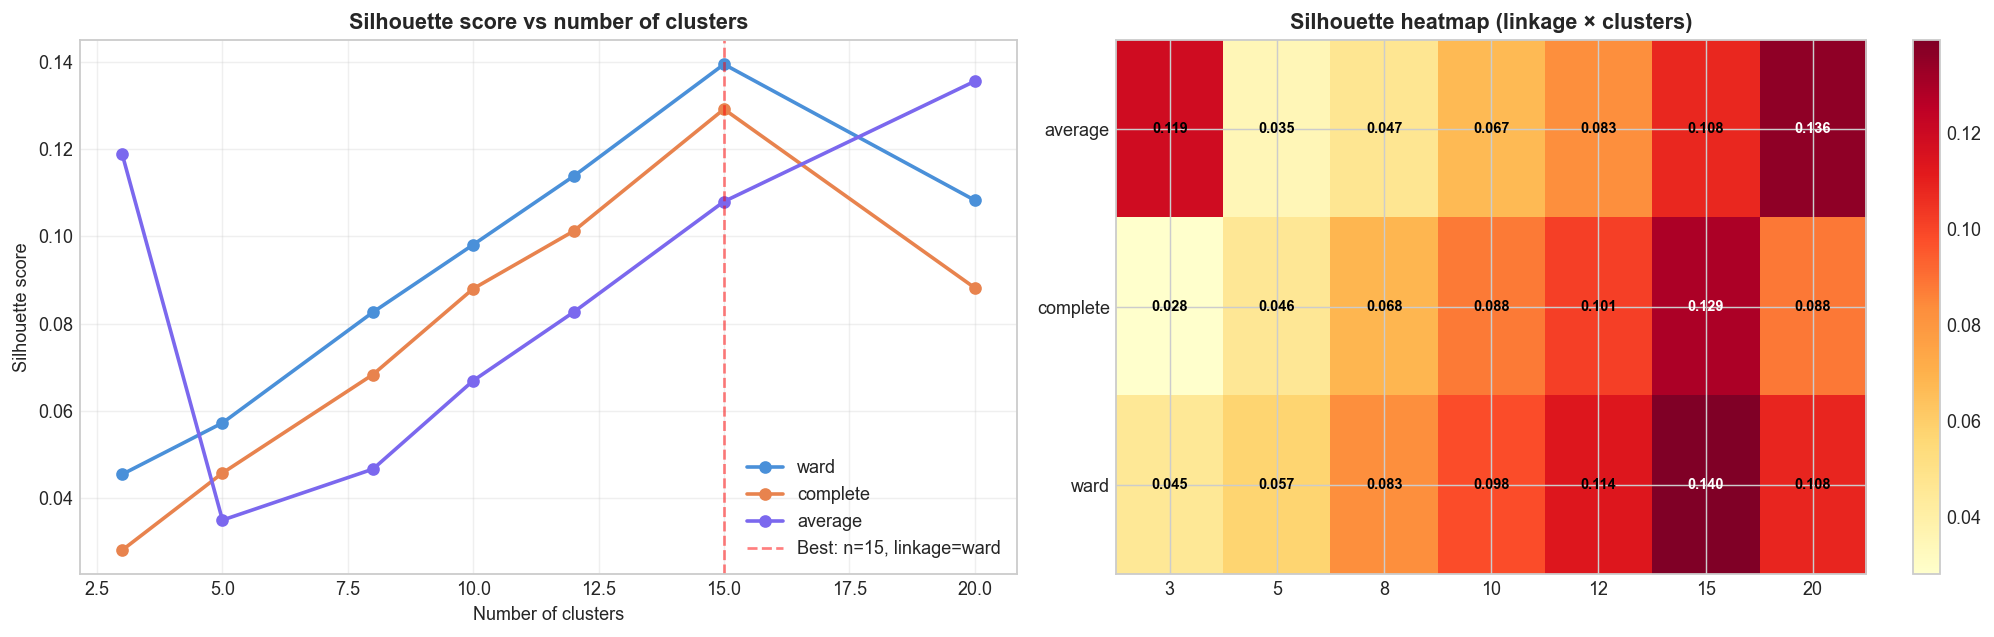


Best Hierarchical config:
  n_clusters=15, linkage=ward | silhouette=0.1395


In [16]:
plot_hierarchical_results(hc_results)

In [17]:
valid_hc = hc_results.dropna(subset=["silhouette"])
if len(valid_hc) > 0:
    best_hc = valid_hc.loc[valid_hc["silhouette"].idxmax()]
    BEST_HC_K = int(best_hc["n_clusters"])
    BEST_HC_LINKAGE = best_hc["linkage"]
    print(f"Best Hierarchical: n={BEST_HC_K}, linkage={BEST_HC_LINKAGE} | "
          f"silhouette={best_hc['silhouette']}")
else:
    BEST_HC_K = BEST_K
    BEST_HC_LINKAGE = "ward"
    print("Using default hierarchical params")

Best Hierarchical: n=15, linkage=ward | silhouette=0.1395


In [18]:
hc_labels = fit_final_hierarchical(X_pca, n_clusters=BEST_HC_K,
                                   linkage_method=BEST_HC_LINKAGE)

✓ Final Hierarchical Clustering fitted  (K=15, linkage=ward)
  Cluster sizes:
    Cluster 0: 3,988 profiles (8.0%)
    Cluster 1: 3,305 profiles (6.6%)
    Cluster 2: 3,280 profiles (6.6%)
    Cluster 3: 3,298 profiles (6.6%)
    Cluster 4: 3,276 profiles (6.6%)
    Cluster 5: 3,422 profiles (6.8%)
    Cluster 6: 3,428 profiles (6.9%)
    Cluster 7: 3,289 profiles (6.6%)
    Cluster 8: 3,172 profiles (6.3%)
    Cluster 9: 3,228 profiles (6.5%)
    Cluster 10: 3,324 profiles (6.6%)
    Cluster 11: 3,194 profiles (6.4%)
    Cluster 12: 3,327 profiles (6.7%)
    Cluster 13: 3,191 profiles (6.4%)
    Cluster 14: 3,278 profiles (6.6%)


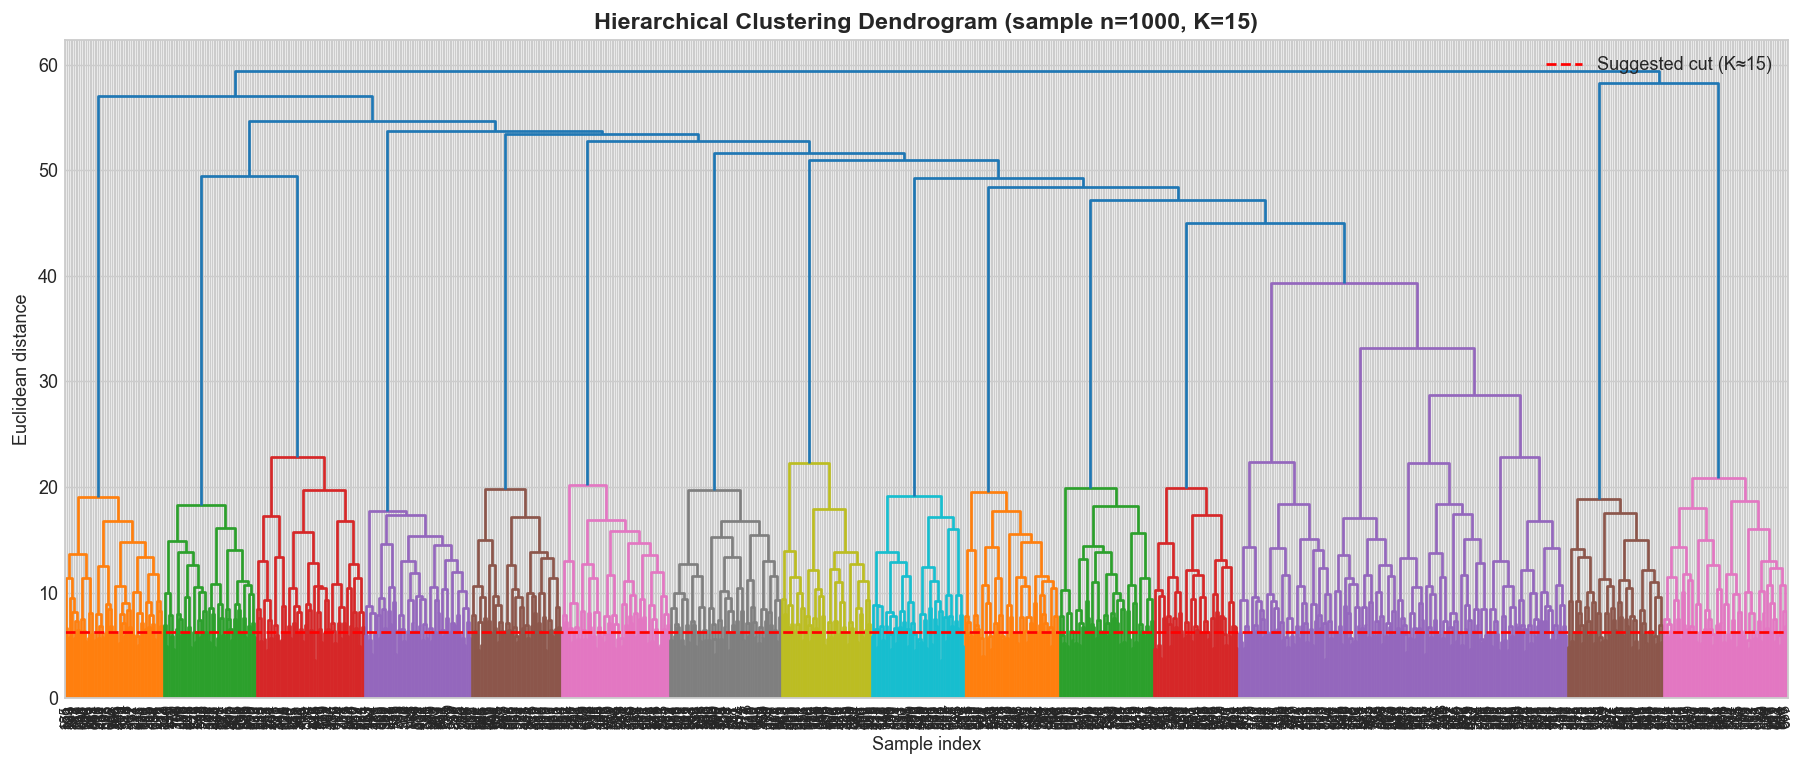

Dendrogram saved → outputs/plots/14_dendrogram.png


In [19]:
plot_dendrogram(X_pca, n_clusters=BEST_HC_K)

In [20]:
hc_summary = profile_clusters(hc_labels, df_original, skill_vocab)
print("Hierarchical Cluster summary:")
print(hc_summary.to_string(index=False))

Hierarchical Cluster summary:
 cluster  size  pct_of_total                                                                       top_skills  dominant_industry        dominant_role  median_exp top_seniority
       0  3988           8.0                                              sql, python, statistics, tableau, r      Biotechnology         Data Analyst        5.50           mid
       1  3305           6.6                  autonomous driving, sensor fusion, python, cad, computer vision         Automotive       Technical Lead        5.30           mid
       2  3280           6.6                                            git, tensorflow, kubernetes, sql, api         Technology    Systems Architect        5.15           mid
       3  3298           6.6                  optimization, renewable energy, plc, engineering, power systems             Energy     Business Analyst        5.30           mid
       4  3276           6.6                     bloomberg, python, quantitative analysis,

## 5. Algorithm Comparison — All Three

All algorithms are evaluated using the same three intrinsic metrics:

| Metric | What it measures | Better when |
|---|---|---|
| Silhouette Score | Cohesion vs separation | Higher (max 1.0) |
| Davies-Bouldin Index | Average cluster similarity | Lower (min 0.0) |
| Calinski-Harabasz Index | Between/within cluster variance ratio | Higher |

In [21]:
kmeans_metrics = evaluate_clustering(X_pca, kmeans_labels)
dbscan_metrics = evaluate_clustering(X_pca, dbscan_labels)
hc_metrics = evaluate_clustering(X_pca, hc_labels)

comparison_df = compare_algorithms({
    "K-Means": kmeans_metrics,
    "DBSCAN": dbscan_metrics,
    "Hierarchical": hc_metrics,
})

print("=" * 80)
print("ALGORITHM COMPARISON")
print("=" * 80)
print(comparison_df.to_string(index=False))
print("=" * 80)

ALGORITHM COMPARISON
   algorithm  silhouette  davies_bouldin  calinski_harabasz  n_clusters  n_noise
     K-Means      0.1494          1.9500            1953.06          15        0
      DBSCAN      0.0885          3.7719             297.09          19    37811
Hierarchical      0.1395          2.1481            1840.58          15        0


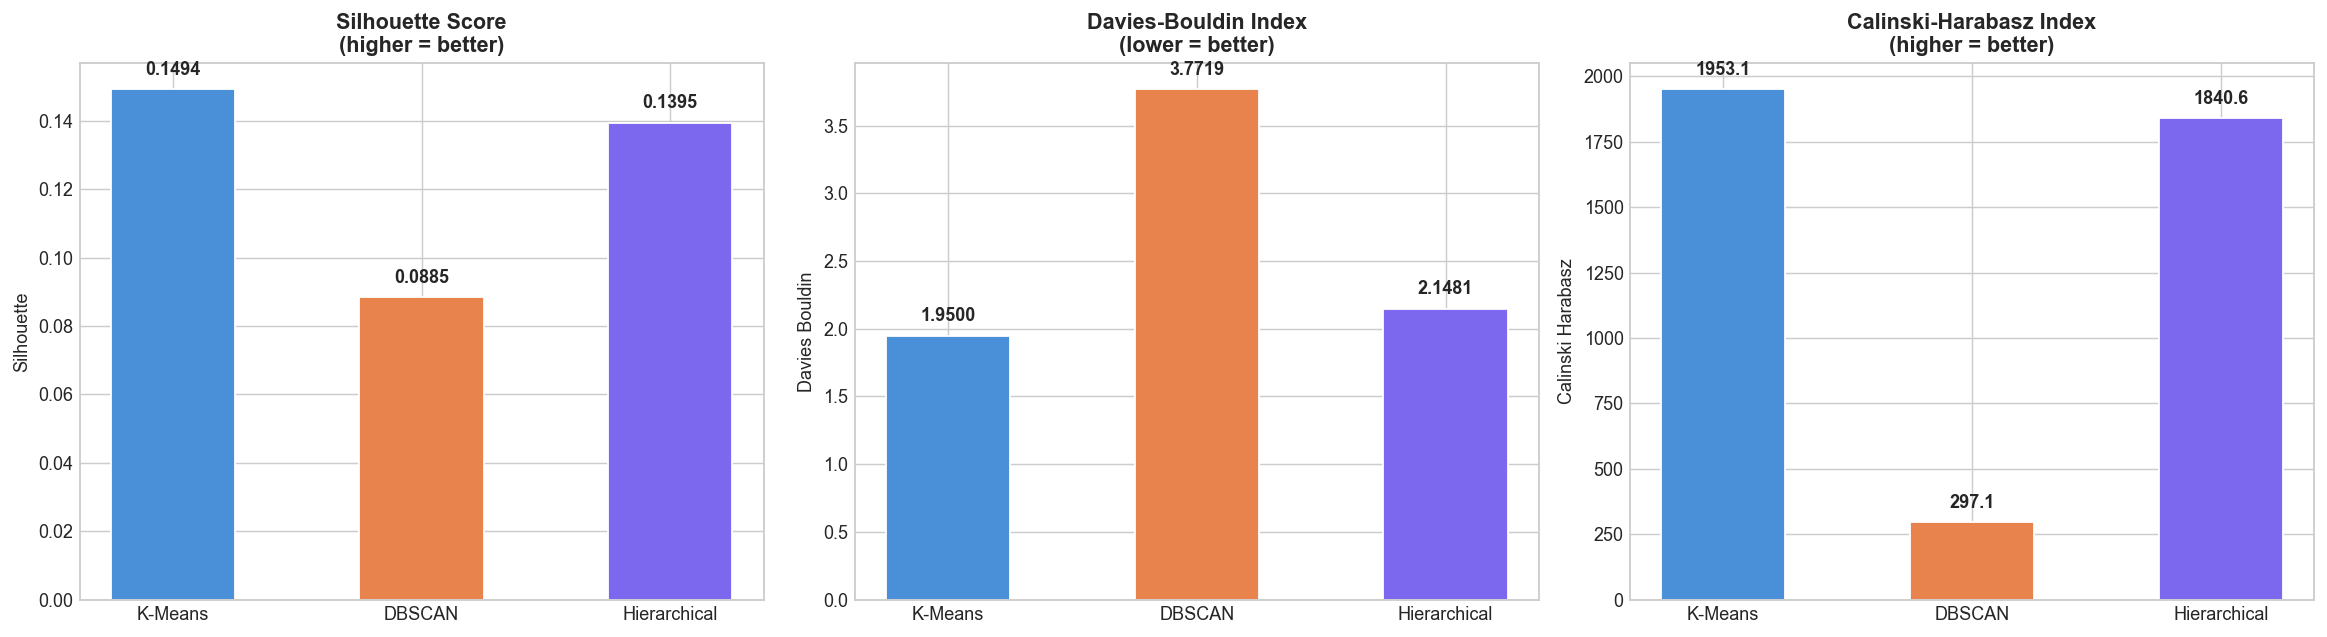


Comparison plot saved → outputs/plots/16_final_comparison.png


In [22]:
metrics_to_plot = ["silhouette", "davies_bouldin", "calinski_harabasz"]
metrics_labels = [
    "Silhouette Score\n(higher = better)",
    "Davies-Bouldin Index\n(lower = better)",
    "Calinski-Harabasz Index\n(higher = better)"
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
algo_colors = {"K-Means": "#4A90D9", "DBSCAN": "#E8834E", "Hierarchical": "#7B68EE"}

for i, (metric, label) in enumerate(zip(metrics_to_plot, metrics_labels)):
    values = comparison_df[metric].values
    algos = comparison_df["algorithm"].values
    colors = [algo_colors.get(a, "#999999") for a in algos]
    
    bars = axes[i].bar(algos, values, color=colors, edgecolor="white", width=0.5)
    
    for bar, val in zip(bars, values):
        if not np.isnan(val) and val is not None:
            axes[i].text(
                bar.get_x() + bar.get_width()/2,
                bar.get_height() + (max(np.nan_to_num(values))*0.02 if max(np.nan_to_num(values)) > 0 else 0.01),
                f"{val:.4f}" if metric != "calinski_harabasz" else f"{val:.1f}",
                ha="center", va="bottom", fontsize=10, fontweight="bold"
            )
    axes[i].set_title(label, fontsize=12, fontweight="bold")
    axes[i].set_ylabel(metric.replace("_", " ").title())

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "16_final_comparison.png"))
plt.show()

print("\nComparison plot saved → outputs/plots/16_final_comparison.png")

### 5a. Cluster Size Distribution

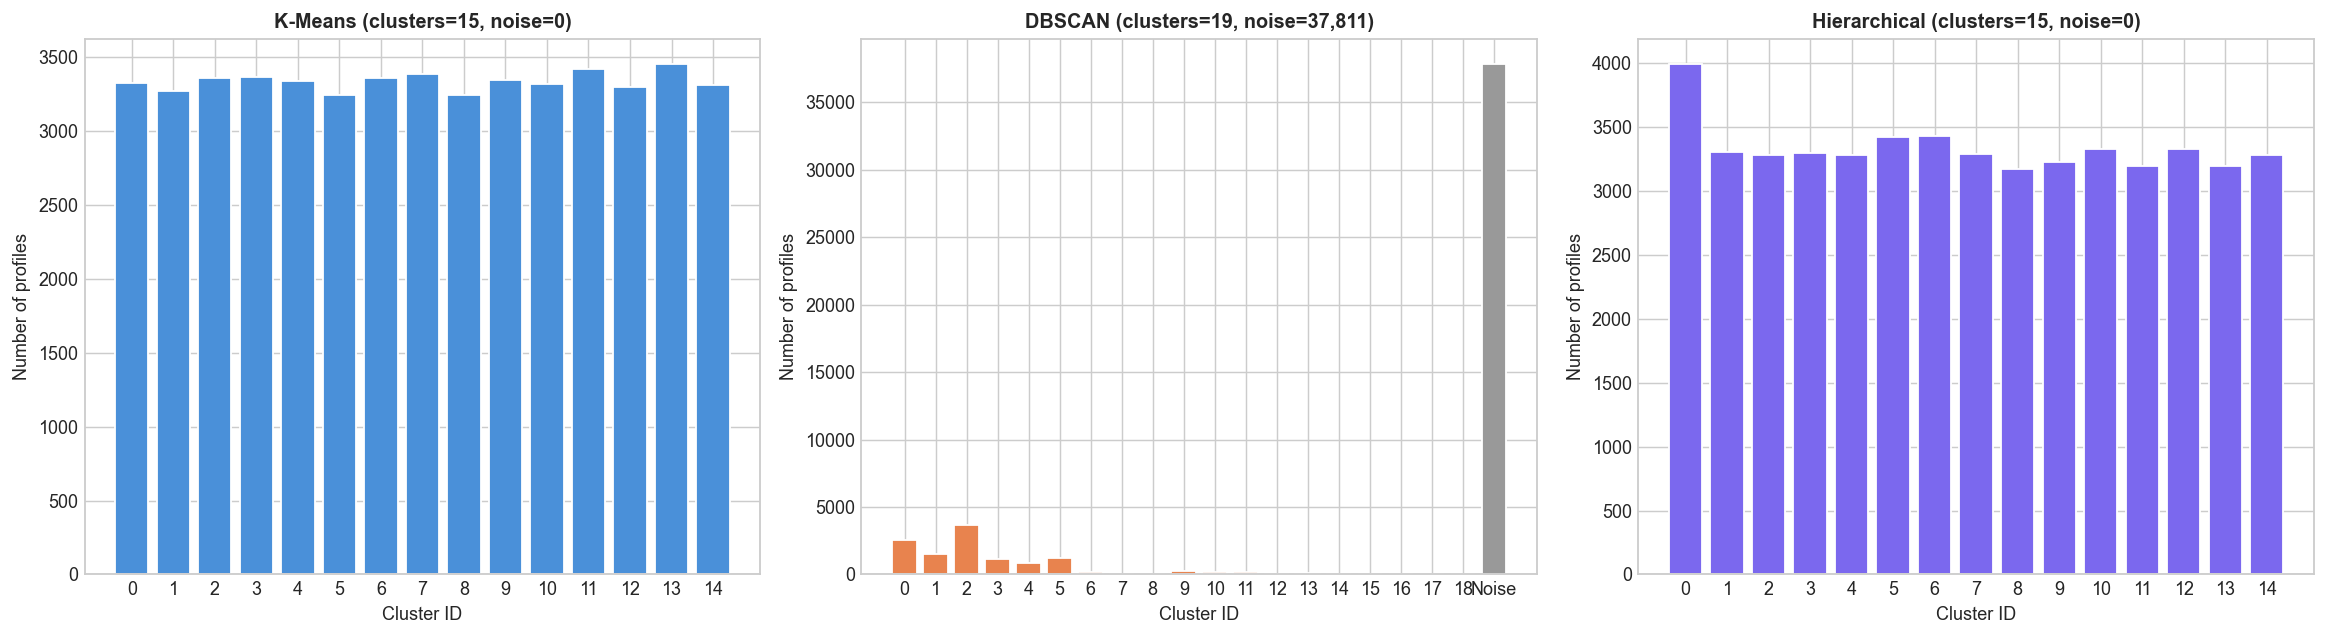

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

algo_configs = [
    ("K-Means", kmeans_metrics, kmeans_labels, "#4A90D9"),
    ("DBSCAN", dbscan_metrics, dbscan_labels, "#E8834E"),
    ("Hierarchical", hc_metrics, hc_labels, "#7B68EE"),
]

for ax, (name, metrics, labels, color) in zip(axes, algo_configs):
    clusters = sorted([k for k in metrics["cluster_sizes"].keys() if k != "noise"])
    sizes = [metrics["cluster_sizes"].get(k, 0) for k in clusters]
    
    ax.bar(range(len(sizes)), sizes, color=color, edgecolor="white")
    
    noise_count = metrics["cluster_sizes"].get("noise", 0)
    if noise_count > 0:
        ax.bar(len(sizes), noise_count, color="#999999", edgecolor="white")
        ax.set_xticks(list(range(len(sizes))) + [len(sizes)])
        ax.set_xticklabels([str(k) for k in clusters] + ["Noise"])
    else:
        ax.set_xticks(range(len(sizes)))
        ax.set_xticklabels([str(k) for k in clusters])
    
    ax.set_title(f"{name} (clusters={len(clusters)}, noise={noise_count:,})",
                 fontsize=11, fontweight="bold")
    ax.set_xlabel("Cluster ID")
    ax.set_ylabel("Number of profiles")

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "17_cluster_sizes.png"))
plt.show()

### 5b. t-SNE Visual Comparison

In [24]:
print("Running t-SNE for comparison visualisation...")
tsne = TSNE(n_components=2, random_state=42, perplexity=40, max_iter=1000)
X_tsne = tsne.fit_transform(X_pca)
print("t-SNE complete.")

Running t-SNE for comparison visualisation...
t-SNE complete.


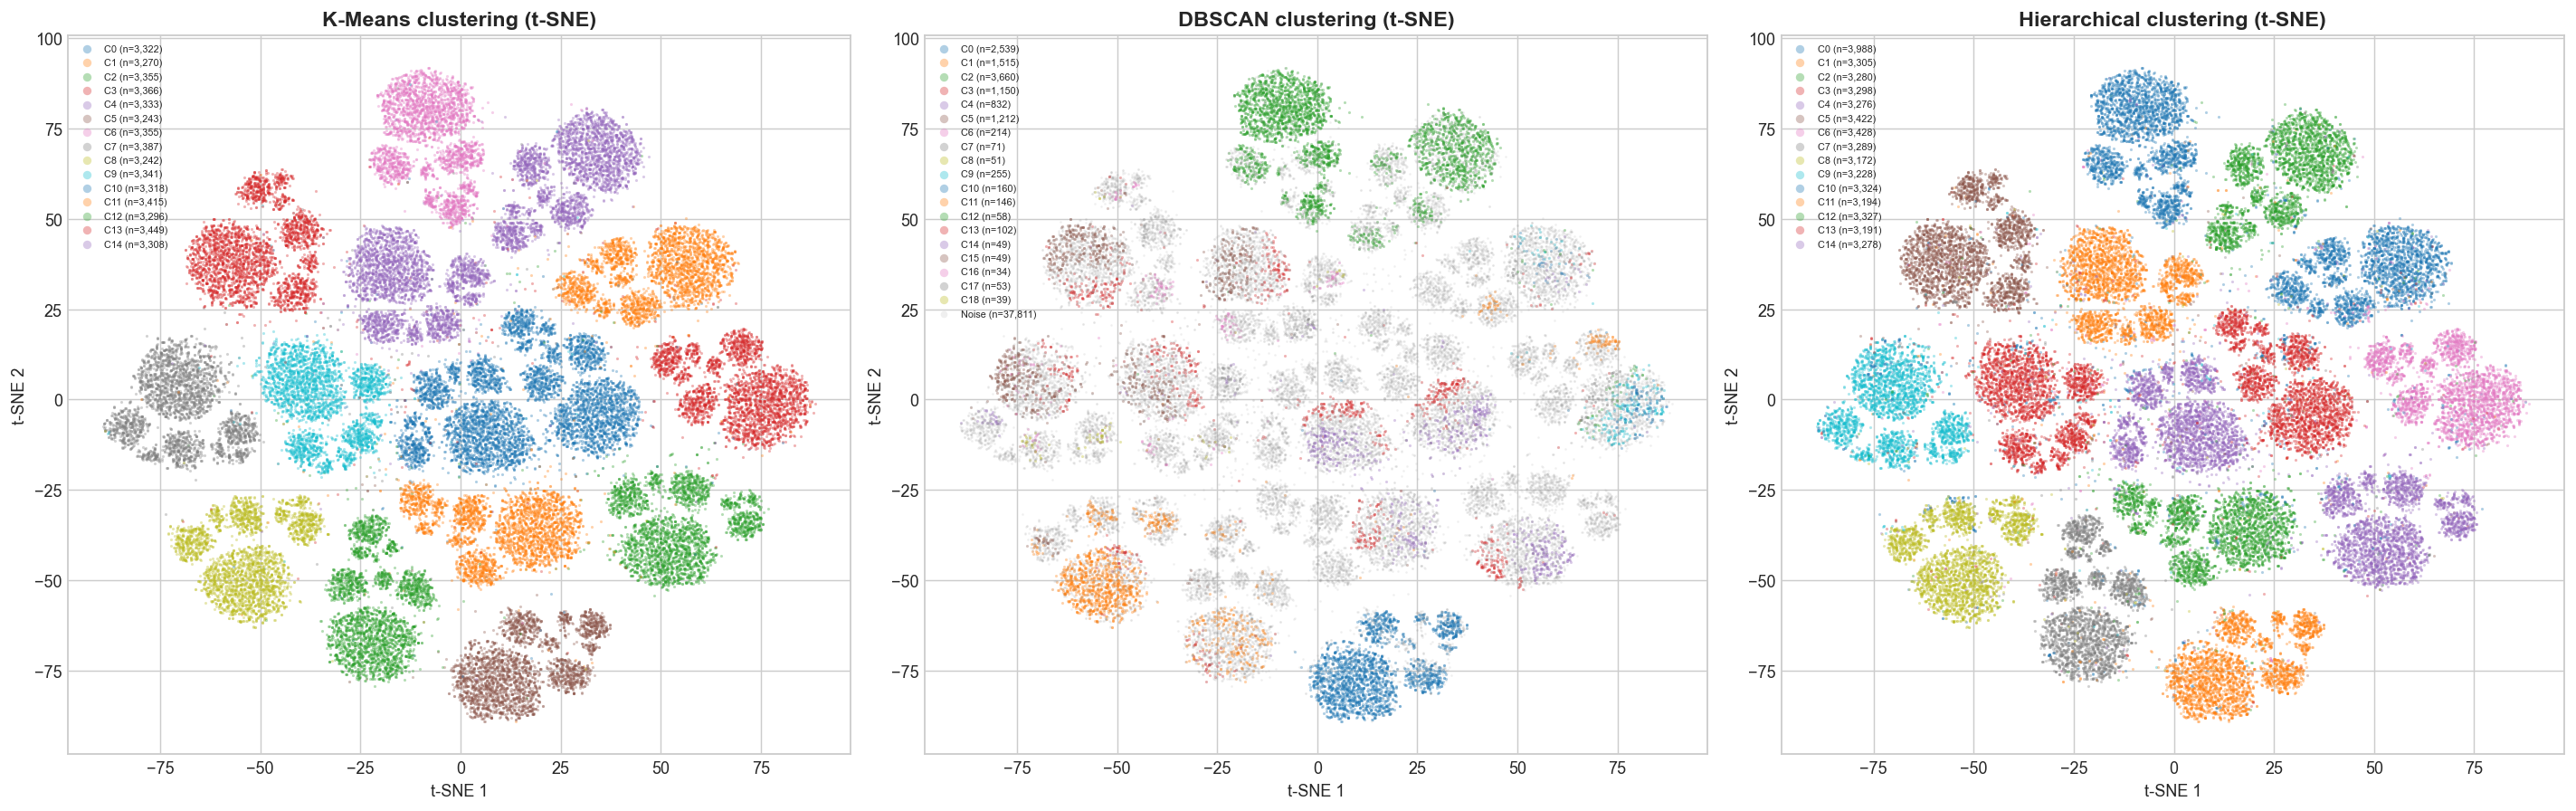

t-SNE comparison saved → outputs/plots/17_tsne_final.png


In [25]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

algo_configs = [
    ("K-Means", kmeans_labels, "#4A90D9"),
    ("DBSCAN", dbscan_labels, "#E8834E"),
    ("Hierarchical", hc_labels, "#7B68EE"),
]

for ax, (name, labels, base_color) in zip(axes, algo_configs):
    unique_clusters = sorted(set(labels) - {-1})
    palette = sns.color_palette("tab10", n_colors=max(len(unique_clusters), 10))
    
    for i, cid in enumerate(unique_clusters):
        mask = labels == cid
        ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                   c=[palette[i % 10]], label=f"C{cid} (n={mask.sum():,})",
                   alpha=0.35, s=3, linewidths=0)
    
    noise_mask = labels == -1
    if noise_mask.sum() > 0:
        ax.scatter(X_tsne[noise_mask, 0], X_tsne[noise_mask, 1],
                   c=["#999999"], label=f"Noise (n={noise_mask.sum():,})",
                   alpha=0.15, s=2, linewidths=0)
    
    ax.set_title(f"{name} clustering (t-SNE)", fontsize=13, fontweight="bold")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.legend(markerscale=3, fontsize=6, loc="upper left")

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "17_tsne_final.png"))
plt.show()

print("t-SNE comparison saved → outputs/plots/17_tsne_final.png")

## 6. Recommendation Demo — Test on a Real Profile

We pick a specific profile and find the 5 most compatible profiles
using the best algorithm's clustering + cosine similarity pipeline.

In [26]:
best_algo = comparison_df.loc[comparison_df["silhouette"].idxmax(), "algorithm"]
print(f"Best algorithm by silhouette: {best_algo}")

if best_algo == "K-Means":
    best_labels = kmeans_labels
elif best_algo == "DBSCAN":
    best_labels = dbscan_labels
else:
    best_labels = hc_labels

Best algorithm by silhouette: K-Means


In [27]:
QUERY_IDX = 42

query = df_original.iloc[QUERY_IDX]
print("=" * 60)
print("QUERY PROFILE")
print("=" * 60)
print(f"Profile ID      : {query['profile_id']}")
print(f"Name            : {query['name']}")
print(f"Role            : {query['current_role']}")
print(f"Company         : {query['current_company']}")
print(f"Industry        : {query['industry']}")
print(f"Seniority       : {query['seniority_level']}")
print(f"Experience      : {query['years_experience']} years")
print(f"Connections     : {query['connections']:,}")
print(f"Location        : {query['location']}")
print(f"Remote pref     : {query['remote_preference']}")
print(f"Skills          : {query['skills']}")
print(f"Goals           : {query['goals']}")
print(f"Needs           : {query['needs']}")
print(f"Can offer       : {query['can_offer']}")
print(f"K-Means Cluster : {int(kmeans_labels[QUERY_IDX])}")
print(f"DBSCAN Cluster  : {int(dbscan_labels[QUERY_IDX])}")
print(f"Hierarchical    : {int(hc_labels[QUERY_IDX])}")

QUERY PROFILE
Profile ID      : PROF-00043
Name            : William Harris
Role            : Scrum Master
Company         : Wells Fargo
Industry        : Media
Seniority       : entry
Experience      : 2.4 years
Connections     : 175
Location        : San Francisco, NC
Remote pref     : onsite
Skills          : ['sql', 'biostatistics', 'spss', 'node.js']
Goals           : ['job opportunities']
Needs           : ['research opportunities', 'project collaboration', 'job referrals']
Can offer       : ['skill training', 'network connections', 'leadership coaching']
K-Means Cluster : 8
DBSCAN Cluster  : -1
Hierarchical    : 8


In [28]:
df_original["cluster"] = best_labels

recommendations = recommend_profiles(
    query_idx   = QUERY_IDX,
    X           = X,
    labels      = best_labels,
    df_original = df_original,
    top_n       = 5
)

print("=" * 60)
print(f"TOP 5 COMPATIBLE PROFILES  ({best_algo} Cluster {int(best_labels[QUERY_IDX])})")
print("=" * 60)

for rank, (_, row) in enumerate(recommendations.iterrows(), start=1):
    print(f"\n{'─' * 60}")
    print(f"Rank {rank}  —  similarity score: {row['similarity_score']:.4f}")
    print(f"  Name        : {row['name']}")
    print(f"  Role        : {row['current_role']}")
    print(f"  Company     : {row['current_company']}")
    print(f"  Industry    : {row['industry']}")
    print(f"  Seniority   : {row['seniority_level']}")
    print(f"  Experience  : {row['years_experience']} years")
    print(f"  Location    : {row['location']}")
    print(f"  Skills      : {row['skills']}")
    print(f"  Goals       : {row['goals']}")
    print(f"  Needs       : {row['needs']}")
    print(f"  Can offer   : {row['can_offer']}")

print(f"\n{'=' * 60}")

TOP 5 COMPATIBLE PROFILES  (K-Means Cluster 8)

────────────────────────────────────────────────────────────
Rank 1  —  similarity score: 0.6146
  Name        : John Martinez
  Role        : ML Engineer
  Company     : Salesforce
  Industry    : Media
  Seniority   : entry
  Experience  : 2.2 years
  Location    : Charlotte, Germany
  Skills      : ['biostatistics', 'simulation', 'html', 'node.js']
  Goals       : ['networking']
  Needs       : ['peer feedback']
  Can offer   : ['research expertise']

────────────────────────────────────────────────────────────
Rank 2  —  similarity score: 0.6093
  Name        : Jessica Nguyen
  Role        : Backend Developer
  Company     : Wells Fargo
  Industry    : Media
  Seniority   : entry
  Experience  : 1.3 years
  Location    : Seattle, Singapore
  Skills      : ['machine learning', 'matlab', 'sql', 'node.js', 'marketing', 'biostatistics']
  Goals       : ['networking', 'startup advice', 'technical expertise']
  Needs       : ['career advice

## 7. Final Summary

In [29]:
print("=" * 80)
print("FINAL RESULTS SUMMARY")
print("=" * 80)
print(f"\nDataset            : {len(df_original):,} profiles")
print(f"Features           : {X.shape[1]} (after preprocessing)")
print(f"PCA dimensions     : {X_pca.shape[1]} "
      f"({pca.explained_variance_ratio_.sum()*100:.1f}% variance)")
print(f"\n{'─' * 80}")
print(comparison_df.to_string(index=False))
print(f"{'─' * 80}")

best_algo = comparison_df.loc[comparison_df["silhouette"].idxmax(), "algorithm"]
print(f"\nBest algorithm by silhouette score: {best_algo}")
print(f"\nAll plots saved to: {PLOTS_DIR}")
print(f"All cluster CSVs saved to: {os.path.join(PROJECT_ROOT, 'outputs', 'clusters')}")

FINAL RESULTS SUMMARY

Dataset            : 50,000 profiles
Features           : 188 (after preprocessing)
PCA dimensions     : 30 (31.7% variance)

────────────────────────────────────────────────────────────────────────────────
   algorithm  silhouette  davies_bouldin  calinski_harabasz  n_clusters  n_noise
     K-Means      0.1494          1.9500            1953.06          15        0
      DBSCAN      0.0885          3.7719             297.09          19    37811
Hierarchical      0.1395          2.1481            1840.58          15        0
────────────────────────────────────────────────────────────────────────────────

Best algorithm by silhouette score: K-Means

All plots saved to: c:\programmes\unsupervised-professional-matching\outputs\plots
All cluster CSVs saved to: c:\programmes\unsupervised-professional-matching\outputs\clusters
